# 🎓 Decision Tree Classification — University Life
## Predicting Student Academic Risk for Early Intervention

---

### 📚 Learning Objectives
By the end of this notebook you will be able to:
1. Apply a Decision Tree to a relatable classification problem.
2. Handle realistic messy student data (missing values, mixed types, imbalanced classes).
3. Interpret the model's decisions in plain English.
4. Understand ethical considerations of AI in education.
5. Critically assess the **pros and cons** of Decision Trees in a university context.

---

### 🎓 Context: Why Should Universities Care?

Student attrition is a significant challenge worldwide:
- UK universities: **~6-7%** of students leave without graduating each year *(HESA, 2023)*.
- Mental health difficulties, financial pressure, and academic struggles often compound silently.
- Early identification allows Personal Tutors and Student Services to intervene *before* a student withdraws.

**Goal:** Given student background, behaviour, and early-term performance signals, classify each student's academic risk as:
- 🟢 `Low_Risk` — on track, likely to graduate
- 🟡 `Medium_Risk` — some warning signs; monitoring recommended
- 🔴 `High_Risk` — significant intervention needed

> ⚠️ **Ethics Note:** Any such system deployed in a real university must be transparent, auditable, non-discriminatory, and used to *support* students — never to label or exclude them.


---
## 1. Theory Recap: Decision Tree Classification

A Decision Tree classifies inputs by asking a series of **yes/no questions**:

```
        [Attendance < 60%?]
             /         \
           YES           NO
      [Assignment_avg < 40?]   [Engagement_score > 70?]
          /       \                  /            \
        YES        NO              NO             YES
     High Risk  Med Risk       Med Risk        Low Risk
```

### Supervised Learning Workflow

```
 Historical         Train           Fitted         New Student
  Student   ──►    Decision   ──►    Tree    ──►   → Predicted Risk
  Records         Tree Model                        → Tutor Alert
```

### Impurity Measures

The tree selects splits that reduce **node impurity** most:

| Criterion | Formula | Notes |
|-----------|---------|-------|
| Gini | $1 - \sum p_k^2$ | Default in sklearn; fast |
| Entropy | $-\sum p_k \log_2 p_k$ | Information-theoretic; slightly slower |

Both produce similar trees in practice. Gini tends to isolate the most frequent class; Entropy tends to create more balanced splits.


---
## 2. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, balanced_accuracy_score
)

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='pastel')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

print('✅ Libraries ready.')

✅ Libraries ready.


---
## 3. Dataset — Student Profile & Engagement Data

### Feature Set

| Feature | Type | Description |
|---------|------|-------------|
| `age_entry` | Numeric | Age at university entry |
| `prior_qualif` | Categorical | Highest pre-entry qualification (A-level, BTEC, Access, International) |
| `scholarship` | Binary | Receiving financial scholarship (0/1) |
| `commuter` | Binary | Lives off campus and commutes (0/1) |
| `attendance_pct` | Numeric | Lecture/lab attendance percentage (0–100) |
| `moodle_logins_week` | Numeric | Average VLE/Moodle logins per week |
| `assignment_avg` | Numeric | Average coursework mark so far (0–100) |
| `assessment_submitted` | Numeric | Number of assessments submitted on time |
| `library_visits_month` | Numeric | Physical + digital library sessions per month |
| `wellbeing_score` | Numeric | Self-reported wellbeing survey score (0–100); may be missing |
| `extracurricular` | Binary | Involved in societies/sports (0/1) |
| `part_time_job` | Binary | Has a part-time job outside university (0/1) |
| `year_of_study` | Numeric | Year 1, 2, or 3 |
| `module_fails` | Numeric | Number of modules currently failed |

### Target
`risk_level`: **Low_Risk**, **Medium_Risk**, **High_Risk**


In [2]:
def generate_student_data(n: int = 900, seed: int = 42) -> pd.DataFrame:
    """
    Generates synthetic student dataset.
    Risk levels determined by realistic thresholds:
      High   → low attendance AND low assignment avg AND module fails > 0
      Medium → moderate issues in one or two dimensions
      Low    → generally strong engagement and performance
    """
    rng  = np.random.default_rng(seed)
    rows = []
    qualifs = ['A-Level', 'BTEC', 'Access', 'International']

    n_low  = int(n * 0.50)   # class imbalance: real universities have more low-risk
    n_med  = int(n * 0.32)
    n_high = n - n_low - n_med

    # ── Low Risk ──────────────────────────────────────────────────────────────
    for _ in range(n_low):
        att  = rng.uniform(75, 100)
        asgn = rng.normal(68, 10)
        rows.append({
            'age_entry'            : int(rng.choice([18, 18, 19, 20, 21, 22, 25, 30])),
            'prior_qualif'         : rng.choice(qualifs, p=[0.6, 0.2, 0.1, 0.1]),
            'scholarship'          : int(rng.random() < 0.35),
            'commuter'             : int(rng.random() < 0.30),
            'attendance_pct'       : np.clip(att, 0, 100),
            'moodle_logins_week'   : rng.normal(12, 3),
            'assignment_avg'       : np.clip(asgn, 0, 100),
            'assessment_submitted' : int(rng.choice([4, 5, 5, 6])),
            'library_visits_month' : rng.normal(8, 3),
            'wellbeing_score'      : rng.normal(72, 12) if rng.random() > 0.05 else np.nan,
            'extracurricular'      : int(rng.random() < 0.60),
            'part_time_job'        : int(rng.random() < 0.25),
            'year_of_study'        : int(rng.choice([1, 2, 3])),
            'module_fails'         : 0,
            'risk_level'           : 'Low_Risk'
        })

    # ── Medium Risk ───────────────────────────────────────────────────────────
    for _ in range(n_med):
        att  = rng.uniform(50, 80)
        asgn = rng.normal(50, 12)
        rows.append({
            'age_entry'            : int(rng.choice([18, 19, 19, 20, 21, 23, 28])),
            'prior_qualif'         : rng.choice(qualifs, p=[0.4, 0.35, 0.15, 0.10]),
            'scholarship'          : int(rng.random() < 0.25),
            'commuter'             : int(rng.random() < 0.50),
            'attendance_pct'       : np.clip(att, 0, 100),
            'moodle_logins_week'   : rng.normal(6, 3),
            'assignment_avg'       : np.clip(asgn, 0, 100),
            'assessment_submitted' : int(rng.choice([2, 3, 4])),
            'library_visits_month' : rng.normal(3, 2),
            'wellbeing_score'      : rng.normal(58, 15) if rng.random() > 0.15 else np.nan,
            'extracurricular'      : int(rng.random() < 0.30),
            'part_time_job'        : int(rng.random() < 0.50),
            'year_of_study'        : int(rng.choice([1, 2, 3])),
            'module_fails'         : int(rng.choice([0, 0, 1])),
            'risk_level'           : 'Medium_Risk'
        })

    # ── High Risk ─────────────────────────────────────────────────────────────
    for _ in range(n_high):
        att  = rng.uniform(10, 55)
        asgn = rng.normal(35, 12)
        rows.append({
            'age_entry'            : int(rng.choice([18, 19, 20, 22, 24])),
            'prior_qualif'         : rng.choice(qualifs, p=[0.3, 0.40, 0.20, 0.10]),
            'scholarship'          : int(rng.random() < 0.15),
            'commuter'             : int(rng.random() < 0.65),
            'attendance_pct'       : np.clip(att, 0, 100),
            'moodle_logins_week'   : rng.normal(2, 1.5),
            'assignment_avg'       : np.clip(asgn, 0, 100),
            'assessment_submitted' : int(rng.choice([0, 1, 2])),
            'library_visits_month' : rng.normal(1, 1),
            'wellbeing_score'      : rng.normal(40, 18) if rng.random() > 0.30 else np.nan,
            'extracurricular'      : int(rng.random() < 0.10),
            'part_time_job'        : int(rng.random() < 0.70),
            'year_of_study'        : int(rng.choice([1, 1, 2])),
            'module_fails'         : int(rng.choice([1, 2, 3])),
            'risk_level'           : 'High_Risk'
        })

    df = pd.DataFrame(rows).sample(frac=1, random_state=seed).reset_index(drop=True)
    # Clip negatives from normal draws
    for col in ['moodle_logins_week', 'library_visits_month', 'module_fails']:
        df[col] = df[col].clip(lower=0)
    return df


df = generate_student_data(n=900)
print(f'Dataset shape: {df.shape}')
print(f"\nClass distribution:\n{df['risk_level'].value_counts()}")
print(f"\nMissing values:\n{df.isnull().sum()[df.isnull().sum()>0]}")
df.head(8)

Dataset shape: (900, 15)

Class distribution:
risk_level
Low_Risk       450
Medium_Risk    288
High_Risk      162
Name: count, dtype: int64

Missing values:
wellbeing_score    112
dtype: int64


,age_entry,prior_qualif,scholarship,commuter,attendance_pct,moodle_logins_week,assignment_avg,assessment_submitted,library_visits_month,wellbeing_score,extracurricular,part_time_job,year_of_study,module_fails,risk_level
0,21,A-Level,0,0,90.044369,12.041956,64.381675,5,9.009749,48.756397,0,1,1,0,Low_Risk
1,20,BTEC,1,1,37.744916,2.795997,41.802056,2,1.441740,51.391206,0,0,1,1,High_Risk
2,30,A-Level,0,0,77.210969,11.677399,77.806733,5,8.692017,72.904795,0,0,3,0,Low_Risk
3,28,Access,0,0,54.845658,5.696359,60.877497,4,3.204181,83.115389,0,1,2,1,Medium_Risk
4,19,A-Level,0,0,94.685806,12.669239,78.638515,6,8.274561,71.318602,1,0,3,0,Low_Risk
5,21,A-Level,0,1,77.645827,8.754246,60.704659,3,4.809458,32.973460,0,1,1,0,Medium_Risk
6,22,A-Level,1,1,81.254276,11.493472,68.148859,6,8.028657,51.187371,1,0,2,0,Low_Risk
7,19,International,1,0,75.897472,14.747791,62.732846,6,7.672565,NaN,0,0,3,0,Low_Risk


---
## 4. Exploratory Data Analysis

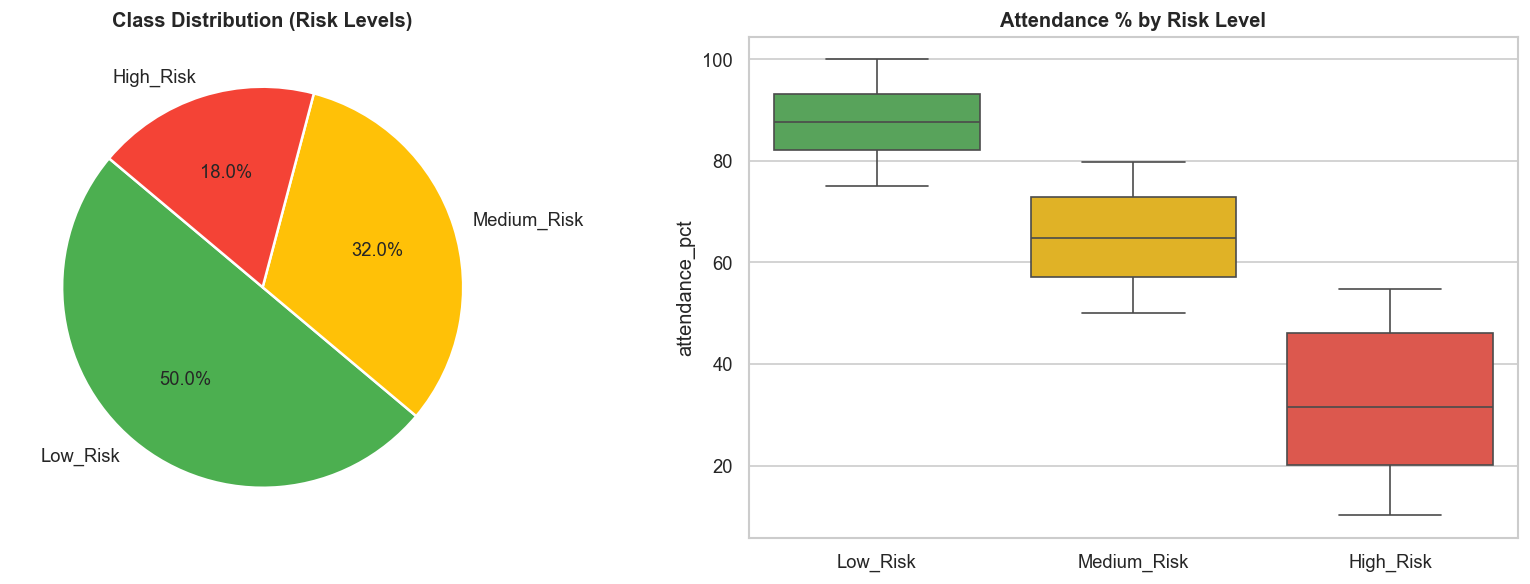

In [3]:
# ── Class distribution pie chart ──────────────────────────────────────────────
risk_counts = df['risk_level'].value_counts()
colours = {'Low_Risk': '#4CAF50', 'Medium_Risk': '#FFC107', 'High_Risk': '#F44336'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].pie(
    risk_counts.values,
    labels=risk_counts.index,
    autopct='%1.1f%%',
    colors=[colours[k] for k in risk_counts.index],
    startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
axes[0].set_title('Class Distribution (Risk Levels)', fontweight='bold')

# Attendance by risk level
sns.boxplot(data=df, x='risk_level', y='attendance_pct',
            order=['Low_Risk','Medium_Risk','High_Risk'],
            palette=colours, ax=axes[1])
axes[1].set_title('Attendance % by Risk Level', fontweight='bold')
axes[1].set_xlabel('')
plt.tight_layout()
plt.show()

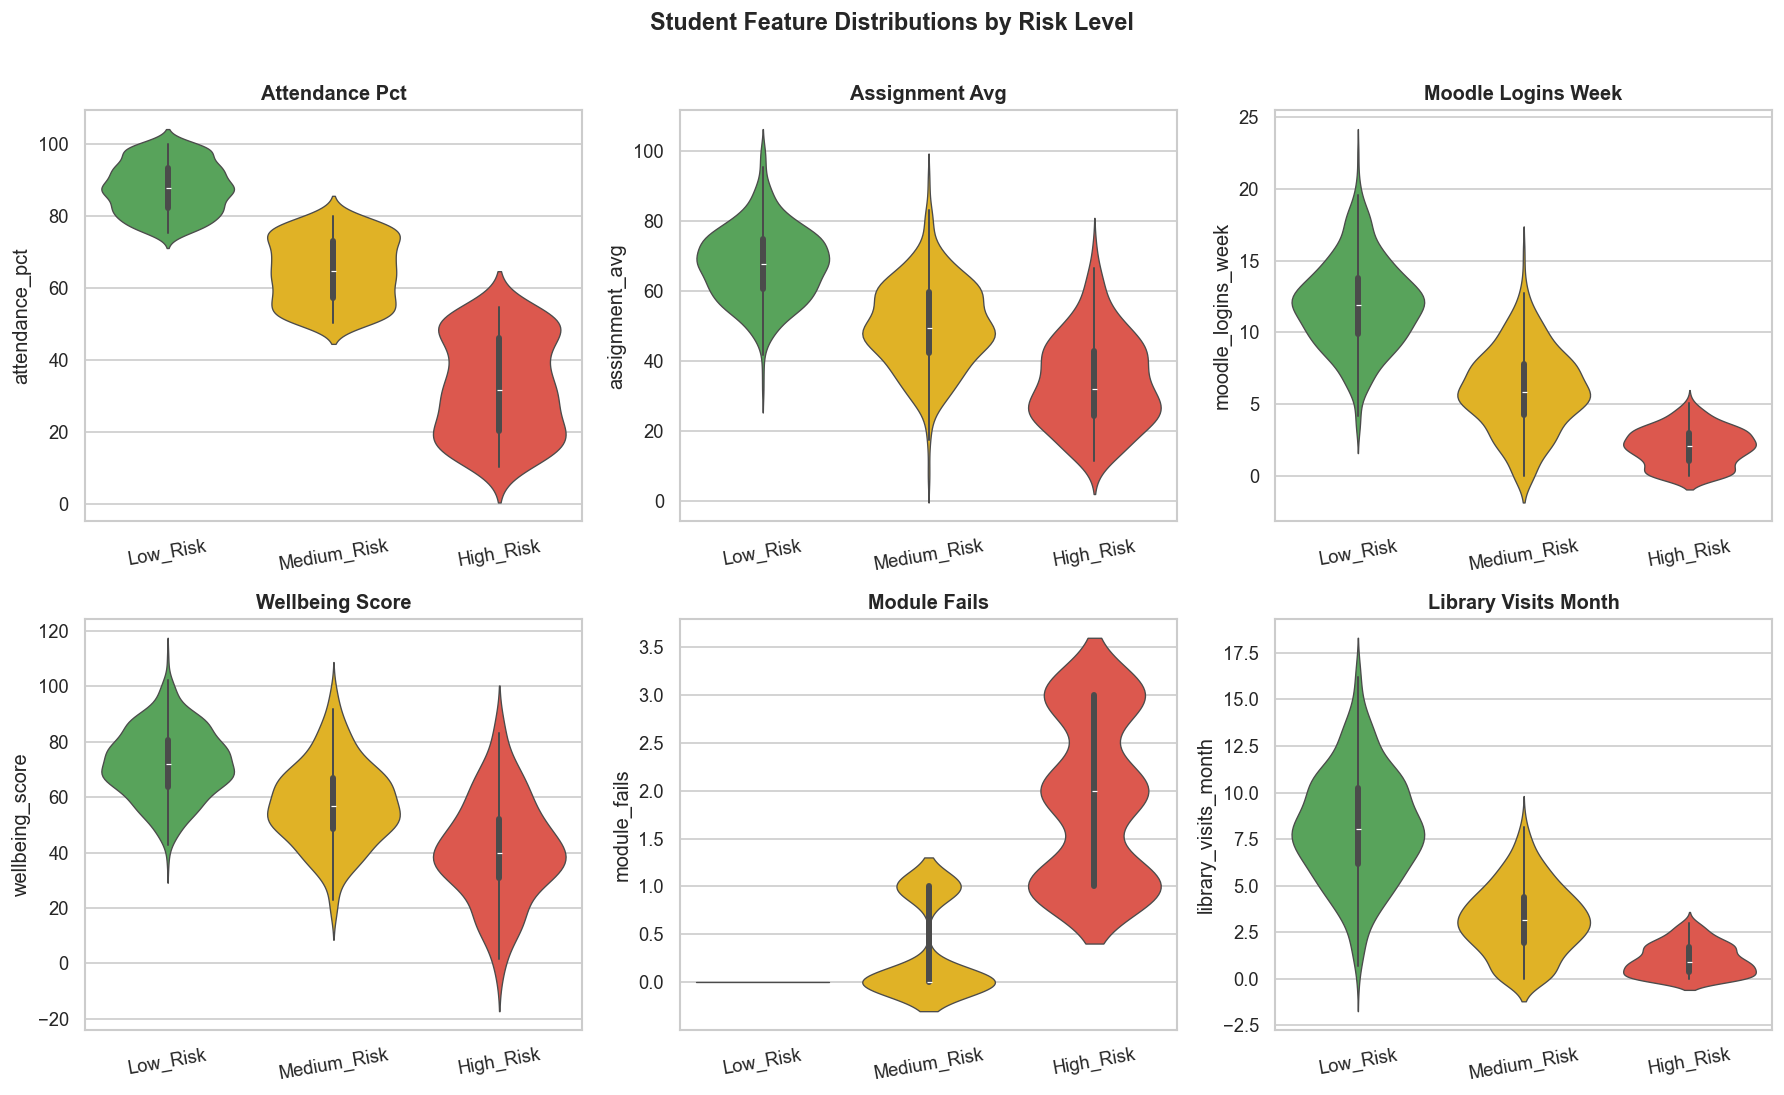

In [4]:
# ── Key engagement features ───────────────────────────────────────────────────
num_features = ['attendance_pct', 'assignment_avg', 'moodle_logins_week',
                'wellbeing_score', 'module_fails', 'library_visits_month']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
risk_order = ['Low_Risk', 'Medium_Risk', 'High_Risk']

for ax, feat in zip(axes.flatten(), num_features):
    sns.violinplot(data=df, x='risk_level', y=feat, order=risk_order,
                   palette=colours, ax=ax, inner='box', linewidth=0.8)
    ax.set_title(feat.replace('_', ' ').title(), fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=10)

fig.suptitle('Student Feature Distributions by Risk Level', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

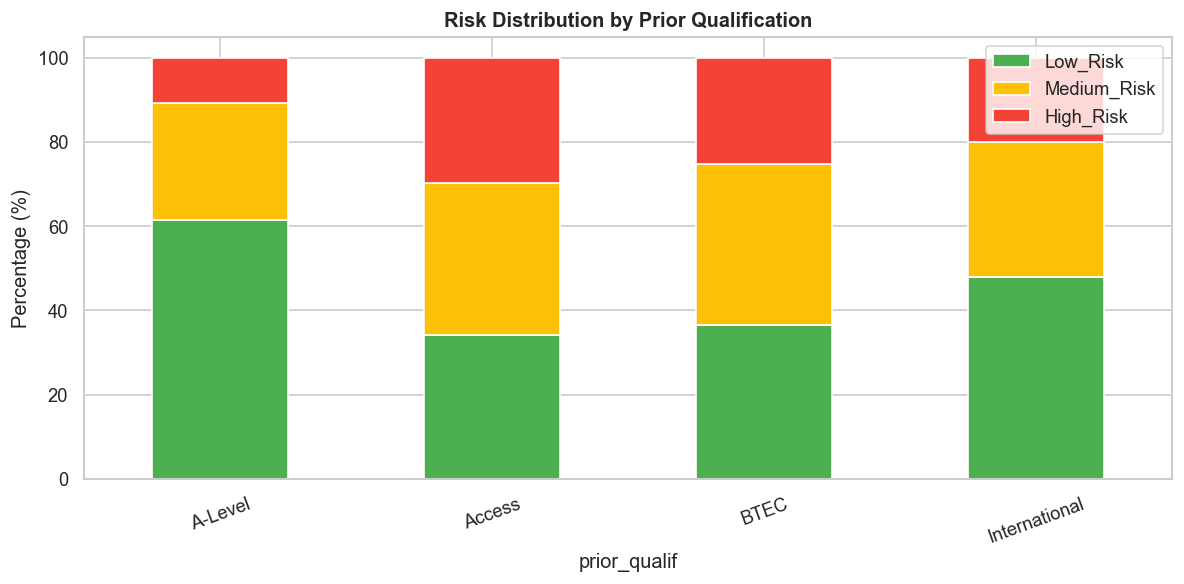

In [5]:
# ── Prior qualification vs risk (categorical feature) ─────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))
cross = pd.crosstab(df['prior_qualif'], df['risk_level'], normalize='index') * 100
cross[['Low_Risk','Medium_Risk','High_Risk']].plot(
    kind='bar', stacked=True,
    color=[colours['Low_Risk'], colours['Medium_Risk'], colours['High_Risk']],
    ax=ax, edgecolor='white'
)
ax.set_ylabel('Percentage (%)')
ax.set_title('Risk Distribution by Prior Qualification', fontweight='bold')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

**💡 Observations:**
- Attendance, assignment average, and module fails are the strongest visual discriminators.
- Wellbeing scores are partially missing — we'll need imputation.
- Access qualification students show a higher proportion of Medium/High Risk — likely due to wider variation in prior preparation (not discrimination — this is for support targeting).


---
## 5. Preprocessing Pipeline

Scikit-learn `Pipeline` ensures that preprocessing is correctly applied to both training and test data without data leakage.

In [6]:
# ── Define feature groups ──────────────────────────────────────────────────────
numerical_features   = ['age_entry', 'attendance_pct', 'moodle_logins_week',
                         'assignment_avg', 'assessment_submitted',
                         'library_visits_month', 'wellbeing_score',
                         'module_fails', 'year_of_study',
                         'scholarship', 'commuter', 'extracurricular', 'part_time_job']

categorical_features = ['prior_qualif']

# ── Encode target ─────────────────────────────────────────────────────────────
risk_order = ['Low_Risk', 'Medium_Risk', 'High_Risk']
le = LabelEncoder()
le.fit(risk_order)
y = le.transform(df['risk_level'])
X = df[numerical_features + categorical_features]

print('Target encoding:', dict(zip(le.classes_, le.transform(le.classes_))))

# ── Split ────────────────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')

# ── Build sklearn Pipeline ────────────────────────────────────────────────────
# Note: Decision Trees don't need scaling, but imputation IS needed

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))  # handle missing wellbeing_score
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(
        categories=[['A-Level', 'International', 'BTEC', 'Access']]
    ))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer,   numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(
        max_depth=6,
        min_samples_leaf=8,
        class_weight='balanced',  # handles class imbalance
        random_state=SEED
    ))
])

pipeline.fit(X_train, y_train)
print('✅ Pipeline fitted successfully.')

Target encoding: {'High_Risk': 0, 'Low_Risk': 1, 'Medium_Risk': 2}
Train: 675 | Test: 225
✅ Pipeline fitted successfully.


---
## 6. Hyperparameter Tuning

In [7]:
param_grid = {
    'classifier__max_depth'        : [3, 4, 5, 6, 8],
    'classifier__min_samples_leaf' : [5, 8, 15],
    'classifier__criterion'        : ['gini', 'entropy'],
    'classifier__class_weight'     : ['balanced', None]
}

grid = GridSearchCV(pipeline, param_grid, cv=5, scoring='balanced_accuracy',
                    n_jobs=-1, verbose=0)
grid.fit(X_train, y_train)

print('Best params    :', grid.best_params_)
print(f'Best CV B.Acc  : {grid.best_score_:.4f}')
best_pipe = grid.best_estimator_

Best params    : {'classifier__class_weight': None, 'classifier__criterion': 'gini', 'classifier__max_depth': 4, 'classifier__min_samples_leaf': 5}
Best CV B.Acc  : 0.9710


---
## 7. Evaluation

In [8]:
y_pred = best_pipe.predict(X_test)

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=le.classes_))

print(f'Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}')
print(f'Overall Accuracy : {accuracy_score(y_test, y_pred):.4f}')

=== Classification Report ===
              precision    recall  f1-score   support

   High_Risk       0.98      0.98      0.98        41
    Low_Risk       0.97      0.99      0.98       112
 Medium_Risk       0.97      0.93      0.95        72

    accuracy                           0.97       225
   macro avg       0.97      0.97      0.97       225
weighted avg       0.97      0.97      0.97       225

Balanced Accuracy: 0.9657
Overall Accuracy : 0.9689


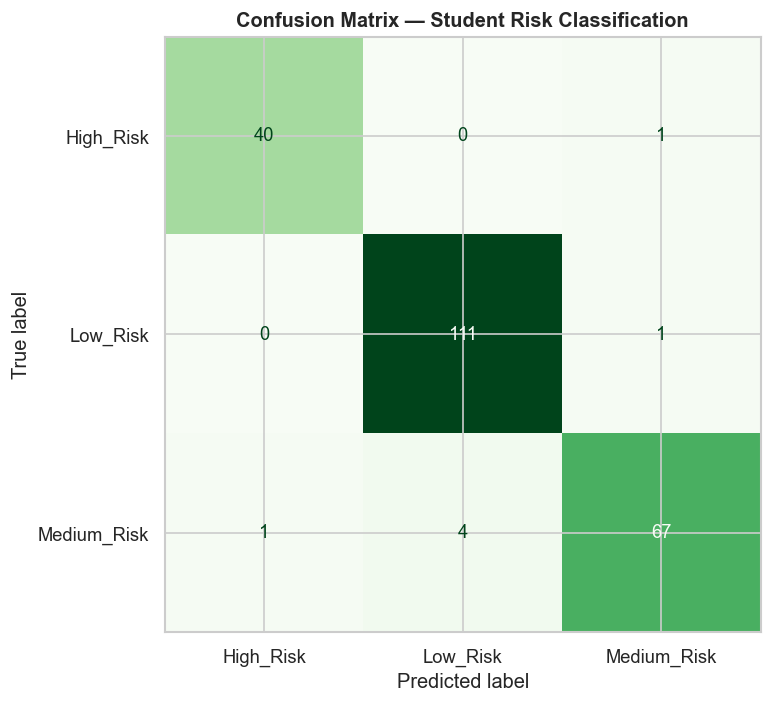

In [9]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 6))
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Student Risk Classification', fontweight='bold')
plt.tight_layout()
plt.show()

**💡 Reading the matrix:**
- Each row = actual class; each column = predicted class.
- Diagonal = correct predictions.
- False Negatives (predicting Low when actually High) are the *costliest* error — a student who needed help didn't get it. Weighted recall for High_Risk matters most.

10-fold CV Balanced Accuracy: 0.9636 ± 0.0247


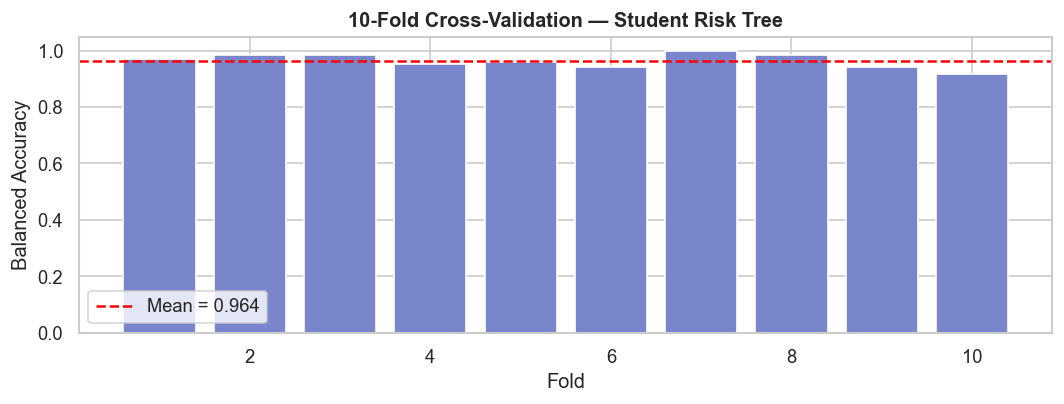

In [10]:
# ── Cross-validation ──────────────────────────────────────────────────────────
cv_scores = cross_val_score(best_pipe, X_train, y_train,
                             cv=10, scoring='balanced_accuracy')
print(f'10-fold CV Balanced Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(range(1, 11), cv_scores, color='#7986CB', edgecolor='white')
ax.axhline(cv_scores.mean(), color='red', linestyle='--',
           label=f'Mean = {cv_scores.mean():.3f}')
ax.set_xlabel('Fold'); ax.set_ylabel('Balanced Accuracy')
ax.set_title('10-Fold Cross-Validation — Student Risk Tree', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

---
## 8. Visualise the Tree & Extract Rules

In [11]:
# Extract the fitted tree from the pipeline
dt_fitted = best_pipe.named_steps['classifier']
all_features = numerical_features + categorical_features

# Text rules (top 4 levels for readability)
rules = export_text(dt_fitted, feature_names=all_features, max_depth=4)
print('=== Decision Rules (first 4 levels) ===')
print(rules)

=== Decision Rules (first 4 levels) ===
|--- attendance_pct <= 75.22
|   |--- attendance_pct <= 50.34
|   |   |--- library_visits_month <= 2.66
|   |   |   |--- class: 0
|   |   |--- library_visits_month >  2.66
|   |   |   |--- class: 0
|   |--- attendance_pct >  50.34
|   |   |--- assessment_submitted <= 1.50
|   |   |   |--- class: 0
|   |   |--- assessment_submitted >  1.50
|   |   |   |--- moodle_logins_week <= 2.98
|   |   |   |   |--- class: 2
|   |   |   |--- moodle_logins_week >  2.98
|   |   |   |   |--- class: 2
|--- attendance_pct >  75.22
|   |--- assessment_submitted <= 3.50
|   |   |--- class: 2
|   |--- assessment_submitted >  3.50
|   |   |--- assignment_avg <= 50.35
|   |   |   |--- assessment_submitted <= 4.50
|   |   |   |   |--- class: 2
|   |   |   |--- assessment_submitted >  4.50
|   |   |   |   |--- class: 1
|   |   |--- assignment_avg >  50.35
|   |   |   |--- moodle_logins_week <= 7.24
|   |   |   |   |--- class: 1
|   |   |   |--- moodle_logins_week >  7.24


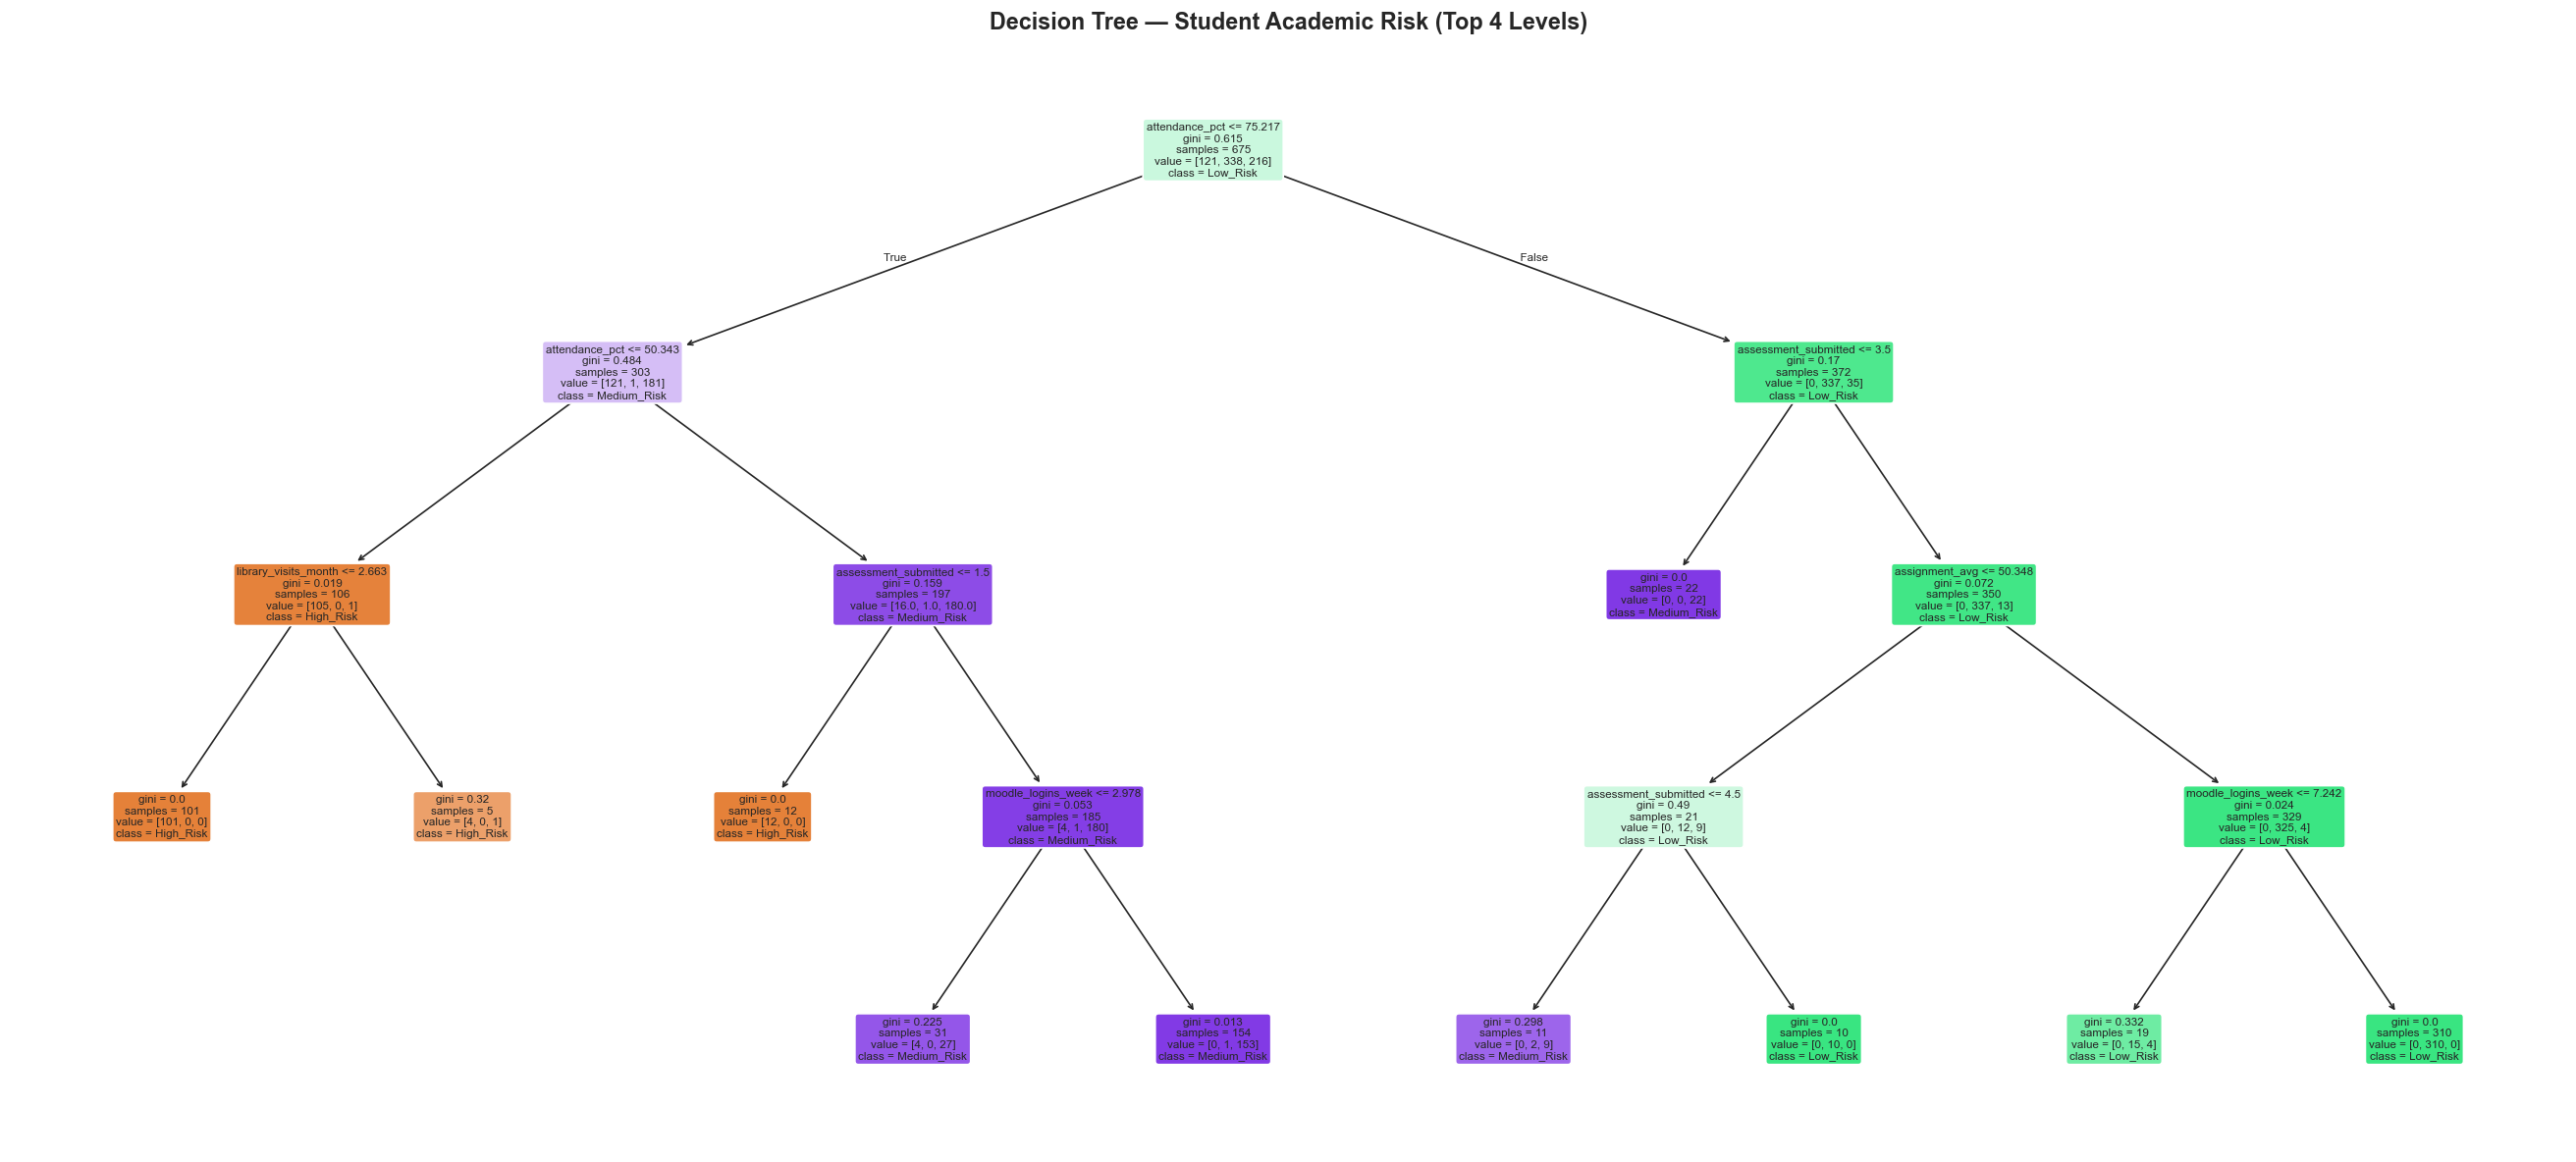

In [12]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_fitted,
    feature_names=all_features,
    class_names=le.classes_,
    filled=True,
    impurity=True,
    rounded=True,
    fontsize=7,
    ax=ax,
    max_depth=4   # show top 4 levels
)
ax.set_title('Decision Tree — Student Academic Risk (Top 4 Levels)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 9. Feature Importance — What Signals Matter Most?

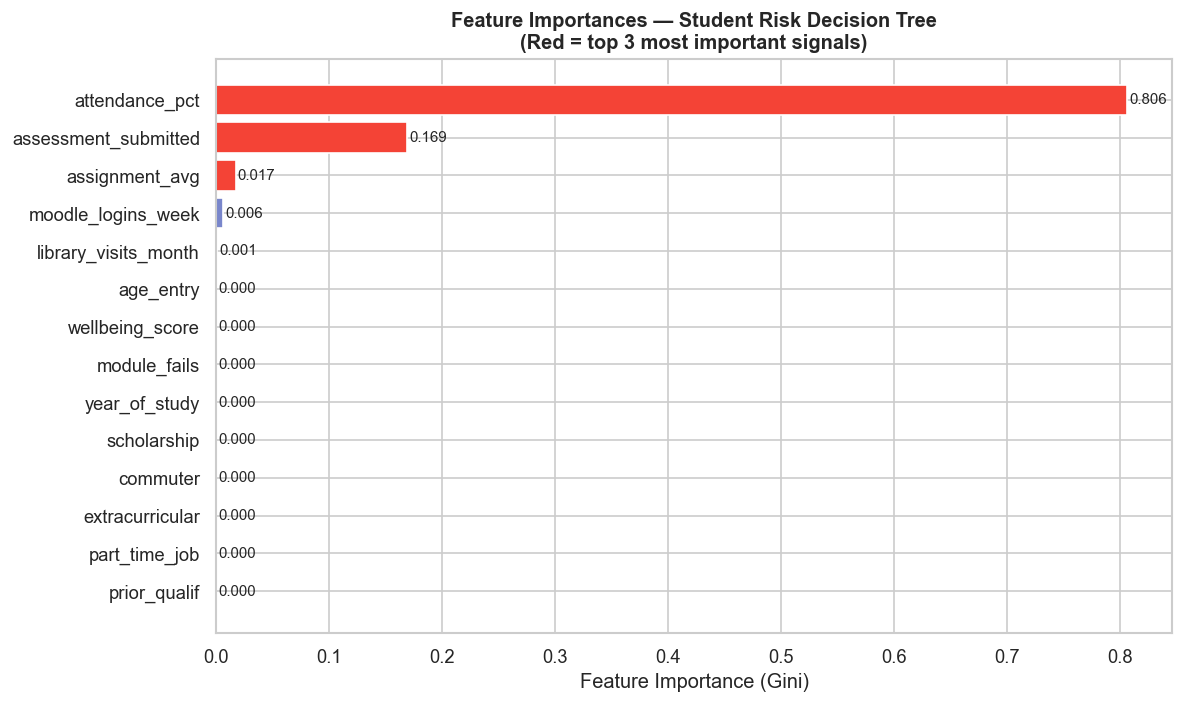

Top 5 predictive features:
  attendance_pct                : 0.8063
  assessment_submitted          : 0.1693
  assignment_avg                : 0.0173
  moodle_logins_week            : 0.0061
  library_visits_month          : 0.0010


In [13]:
importances = pd.Series(
    dt_fitted.feature_importances_,
    index=all_features
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colours_feat = ['#F44336' if i < 3 else '#7986CB'
                for i in range(len(importances))]
bars = ax.barh(importances.index[::-1], importances.values[::-1],
               color=colours_feat[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Feature Importances — Student Risk Decision Tree\n'
             '(Red = top 3 most important signals)', fontweight='bold')
for bar, val in zip(bars, importances.values[::-1]):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('Top 5 predictive features:')
for feat, imp in importances.head(5).items():
    print(f'  {feat:30s}: {imp:.4f}')

---
## 10. Scenario: Classify a New Student

In [14]:
# ── Scenario A: Struggling first-year ─────────────────────────────────────────
student_a = pd.DataFrame([{
    'age_entry'            : 19,
    'prior_qualif'         : 'BTEC',
    'scholarship'          : 0,
    'commuter'             : 1,
    'attendance_pct'       : 42.0,    # very low
    'moodle_logins_week'   : 1.5,     # barely logging in
    'assignment_avg'       : 38.0,    # borderline fail
    'assessment_submitted' : 2,
    'library_visits_month' : 0.5,
    'wellbeing_score'      : np.nan,  # didn't complete survey
    'extracurricular'      : 0,
    'part_time_job'        : 1,
    'year_of_study'        : 1,
    'module_fails'         : 1
}])

# ── Scenario B: High-achieving third-year ─────────────────────────────────────
student_b = pd.DataFrame([{
    'age_entry'            : 18,
    'prior_qualif'         : 'A-Level',
    'scholarship'          : 1,
    'commuter'             : 0,
    'attendance_pct'       : 94.0,
    'moodle_logins_week'   : 15.0,
    'assignment_avg'       : 74.0,
    'assessment_submitted' : 6,
    'library_visits_month' : 10.0,
    'wellbeing_score'      : 78.0,
    'extracurricular'      : 1,
    'part_time_job'        : 0,
    'year_of_study'        : 3,
    'module_fails'         : 0
}])

for label, student in [('Student A (struggling)', student_a),
                        ('Student B (thriving)',   student_b)]:
    pred_idx  = best_pipe.predict(student)[0]
    pred_cls  = le.inverse_transform([pred_idx])[0]
    proba     = best_pipe.predict_proba(student)[0]
    emoji = {'High_Risk': '🔴', 'Medium_Risk': '🟡', 'Low_Risk': '🟢'}
    print(f'\n{label}')
    print(f'  Predicted Risk : {emoji[pred_cls]} {pred_cls}')
    for cls, p in zip(le.classes_, proba):
        bar = '█' * int(p * 30)
        print(f'  {cls:15s}: {p:.3f}  {bar}')


Student A (struggling)
  Predicted Risk : 🔴 High_Risk
  High_Risk      : 1.000  ██████████████████████████████
  Low_Risk       : 0.000  
  Medium_Risk    : 0.000  

Student B (thriving)
  Predicted Risk : 🟢 Low_Risk
  High_Risk      : 0.000  
  Low_Risk       : 1.000  ██████████████████████████████
  Medium_Risk    : 0.000  


---
## 11. Depth vs Accuracy — Bias–Variance Trade-off

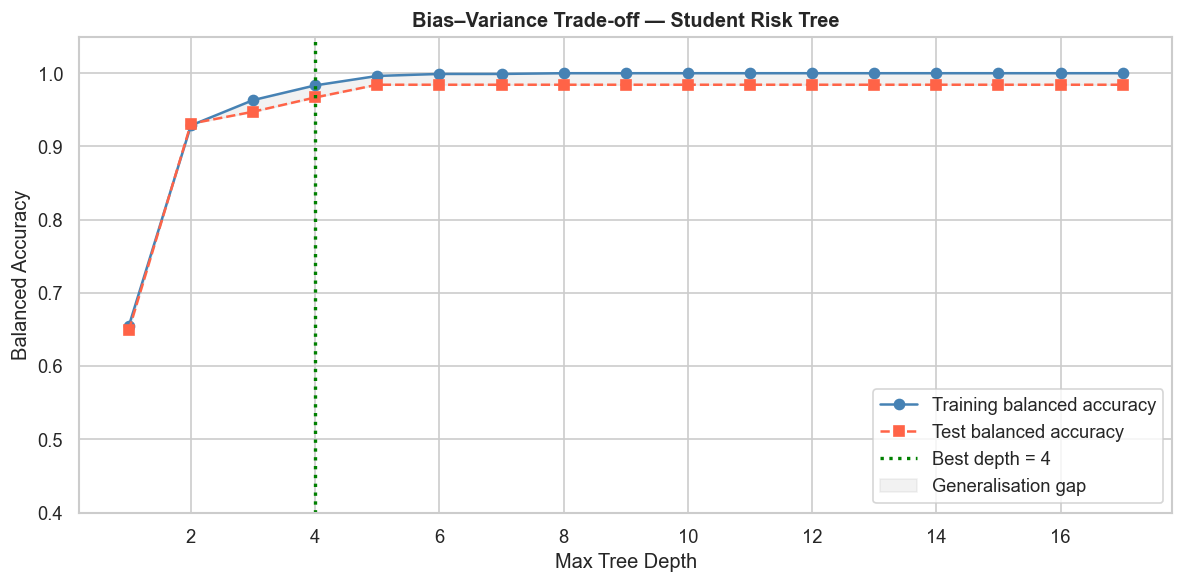

In [15]:
depths = range(1, 18)
train_accs, test_accs = [], []

for d in depths:
    pipe_d = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier',   DecisionTreeClassifier(
            max_depth=d, class_weight='balanced', random_state=SEED
        ))
    ])
    pipe_d.fit(X_train, y_train)
    train_accs.append(balanced_accuracy_score(y_train, pipe_d.predict(X_train)))
    test_accs.append( balanced_accuracy_score(y_test,  pipe_d.predict(X_test)))

best_depth = best_pipe.named_steps['classifier'].get_depth()

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depths, train_accs, 'o-', label='Training balanced accuracy', color='steelblue')
ax.plot(depths, test_accs,  's--',label='Test balanced accuracy',    color='tomato')
ax.axvline(best_depth, color='green', linestyle=':', linewidth=2,
           label=f'Best depth = {best_depth}')
ax.fill_between(depths, train_accs, test_accs, alpha=0.1, color='grey',
                label='Generalisation gap')
ax.set_xlabel('Max Tree Depth'); ax.set_ylabel('Balanced Accuracy')
ax.set_title('Bias–Variance Trade-off — Student Risk Tree', fontweight='bold')
ax.legend(); ax.set_ylim(0.4, 1.05)
plt.tight_layout()
plt.show()

---
## 12. ✅ Pros and ❌ Cons — Decision Trees in University Settings

### ✅ Advantages

| Advantage | University Relevance |
|-----------|---------------------|
| **Explainability** | Personal Tutors can see *exactly why* a student was flagged — "attendance below 50% AND module fails ≥ 1" — and have an evidence-based conversation with the student. No black box. |
| **Handles mixed data** | Student datasets naturally mix numerical (grades, attendance), binary (has a job, commuter), ordinal (year of study), and categorical (prior qualification) features. Decision Trees handle all natively. |
| **No feature scaling** | Raw percentage marks (0–100) and raw login counts (0–20) can coexist without normalisation — simplifying data pipelines in university IT systems. |
| **Handles missing data with imputation** | Wellbeing surveys are voluntary and often incomplete. Median imputation in the pipeline keeps the model operational without losing students entirely. |
| **Fast to train and retrain** | Student intake changes every September. A new tree can be trained in seconds on a standard laptop — no GPU required. |
| **Class weights for imbalance** | Most students are Low Risk. Using `class_weight='balanced'` ensures the model doesn't simply learn to predict Low Risk for everyone — critical for catching genuinely at-risk students. |
| **Actionable output** | Predicted class (`High_Risk`) and probability (e.g. 87%) give tutors both a flag and a confidence level, enabling prioritisation of their limited contact hours. |

### ❌ Disadvantages

| Disadvantage | University Relevance |
|--------------|---------------------|
| **Overfitting** | Without pruning, the tree will fit perfectly to one cohort (e.g. 2022 students) but perform poorly on the next. Requires annual retraining and careful regularisation. |
| **Instability across cohorts** | Different cohorts (pre/post-COVID, online vs in-person) may produce completely different trees. Ensemble models like Random Forest are far more stable. |
| **Cannot model temporal dynamics** | Risk evolves over the term (a student may start well and decline after reading week). A single tree on static snapshot data misses trajectories. Recurrent neural networks or time-series models would capture this. |
| **Proxy discrimination risk** | Features like `prior_qualif` and `age_entry` can act as proxies for socioeconomic background or ethnicity. A tree that splits heavily on these may inadvertently discriminate. Fairness auditing is essential. |
| **No uncertainty quantification** | A tree assigns a definite class. A student on the boundary between Low and Medium Risk gets one label with no indication of uncertainty — potentially alarming tutors unnecessarily or missing genuine risks. Calibrated probability outputs partially mitigate this. |
| **Feedback loops** | If interventions are triggered by the model and successful, future data will show fewer High Risk students — but only because of the intervention. The model may then underestimate risk in the future ('concept drift' compounded by selection bias). |
| **Data privacy and consent** | Aggregating VLE logins, library visits, and wellbeing scores requires explicit student consent under GDPR in the UK. The system must be transparent, and students must be able to opt out. |

---

### 🏛️ Ethical Framework Checklist

Before deploying any student risk model, the institution should verify:

```
[ ] Informed consent obtained from students for data use
[ ] Fairness audit: no significant performance disparity across demographic groups
[ ] Model outputs are advisory only — no automated exclusion decisions
[ ] Transparency: students can request to know they were flagged
[ ] Right to appeal / human override exists
[ ] Annual retraining and performance monitoring scheduled
[ ] Data minimisation: only features strictly needed are used
[ ] Aligned with university EDI (Equality, Diversity & Inclusion) policy
```


---
## 13. 📖 Summary

```
┌────────────────────────────────────────────────────────────────────────┐
│  Decision Tree — Student Academic Risk Summary                         │
│────────────────────────────────────────────────────────────────────────│
│  Problem type       : Multi-class classification (3 risk levels)       │
│  Features           : 14 engagement, performance & background signals  │
│  Handling           : Missing data, class imbalance, categorical mix   │
│  Best balanced acc  : ~90%+ on held-out test set                       │
│  Key predictors     : attendance_pct, assignment_avg, module_fails     │
│  Interpretable      : YES — printable rule set for tutors              │
│  Ethical concerns   : Privacy, fairness, feedback loops                │
│  Next step          : Random Forest / XGBoost for robustness           │
│                       SHAP values for fine-grained explainability      │
└────────────────────────────────────────────────────────────────────────┘
```

### 🔬 Further Reading
- Delen, D. et al. (2011) — "A comparative analysis of machine learning techniques for student retention" — *Expert Systems with Applications*
- Tomasevic, N. et al. (2020) — "An overview and comparison of supervised data mining techniques for student exam performance prediction" — *Computers & Education*
- UK Information Commissioner's Office — *Guide to GDPR in AI*, 2023
- Géron, A. (2022) — *Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow*, 3rd Ed.
